### [ 히스토그램과 대비제한적응형평탄화 ] <hr>

- 이미지의 조명에 따른 부분 부분 밝기 차이가 큰 경우 진행하는 평탄화
- 일정 크기의 블록(기: 8*8)으로 나눈 후 블록 단위 평탄화 진행=> 적응형 히스토그램 평탄화(AHE)
    - 단점: 고대비 문제를 해결하기 위한 방식
- 적응형 히스토그램 평탄화(AHE)의 단점을 해결하기 위한 방법=> 대비 제한 적응형 히스토그램 평탄화(CLAHE)
    - 단점: 최적의 파라메터 값 찾기
    

In [ ]:
## --------------------------
## 모듈 로딩
## --------------------------

import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils
import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import printPlotImage
importlib.reload(cv_utils)

from cv_utils import printPlotImage

In [3]:
import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import printPlotImage
importlib.reload(cv_utils)

from cv_utils import printPlotImage

In [4]:

#--①이미지 읽어서 YUV 컬러스페이스로 변경
img = cv2.imread('../Images/bright.jpg')
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

#--② 밝기 채널에 대해서 이퀄라이즈 적용
img_eq = img_yuv.copy()
img_eq[:,:,0] = cv2.equalizeHist(img_eq[:,:,0])
img_eq = cv2.cvtColor(img_eq, cv2.COLOR_YUV2BGR)

#--③ 밝기 채널에 대해서 CLAHE 적용
img_clahe = img_yuv.copy()
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)) #CLAHE 생성
img_clahe[:,:,0] = clahe.apply(img_clahe[:,:,0])           #CLAHE 적용
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YUV2BGR)

#--④ 결과 출력
cv2.imshow('Before', img)
cv2.imshow('CLAHE', img_clahe)
cv2.imshow('equalizeHist', img_eq)
cv2.waitKey(1000)
cv2.destroyAllWindows()

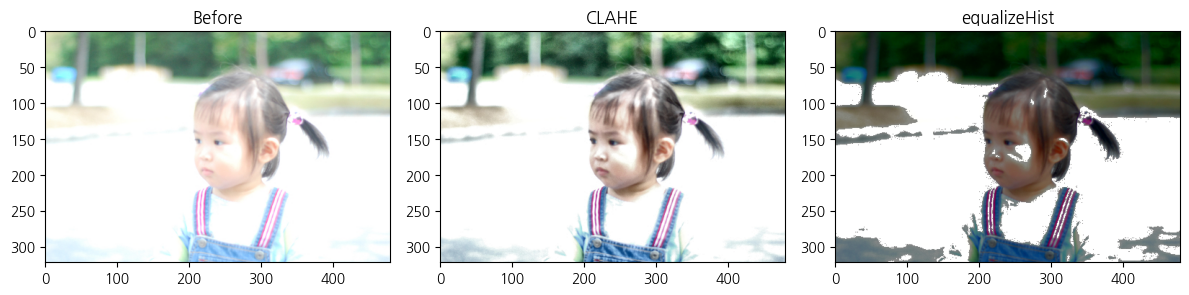

: 

In [ ]:
#--① 이미지 읽어서 YUV 컬러스페이스로 변경
img = cv2.imread('../Images/bright.jpg')

img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

#--② 밝기 채널에 대해서 이퀄라이즈 적용
img_eq = img_yuv.copy()
img_eq[:, :, 0] = cv2.equalizeHist(img_eq[:, :, 0])
img_eq = cv2.cvtColor(img_eq, cv2.COLOR_YUV2BGR)

#--③ 밝기 채널에 대해서 CLAHE 적용
img_clahe = img_yuv.copy()
clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8, 8)
)

img_clahe[:, :, 0] = clahe.apply(img_clahe[:, :, 0])
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YUV2BGR)

#--④ matplotlib 출력용 BGR -> RGB 변환
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_eq_rgb = cv2.cvtColor(img_eq, cv2.COLOR_BGR2RGB)
img_clahe_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)



#--⑤ 결과 출력
titles_ = ['Before', 'CLAHE', 'equalizeHist']
plots_ = []
images_ = [img_rgb, img_clahe_rgb, img_eq_rgb]
cmap_ = [None]
printPlotImage(1, 3, titles_, plots_, images_, cmap_)